Steps:
- get 100 year flood zones
- clip to far rockaway nta polygon
- get pluto endpoint (to apportion population to)
- proportional split census blocks to flood zones
- observe results
- then map in pluto by land use- see the uneven distribution of residential land use in flood zones
- then apportion population by residential units in pluto, and map that
- far rockaway nta polygon: https://data.cityofnewyork.us/resource/9nt8-h7nd.json?$query=SELECT%20borocode%2C%20boroname%2C%20countyfips%2C%20nta2020%2C%20ntaname%2C%20ntaabbrev%2C%20ntatype%2C%20cdta2020%2C%20cdtaname%2C%20shape_leng%2C%20shape_area%2C%20the_geom%20SEARCH%20%22far%22

In [6]:
%load_ext autoreload
%autoreload 2
from cdptools import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import geopandas as gpd
import requests

In [8]:
far_rockaway_gdf = gpd.read_file(
    "https://data.cityofnewyork.us/resource/9nt8-h7nd.geojson?$query=SELECT%20borocode%2C%20boroname%2C%20countyfips%2C%20nta2020%2C%20ntaname%2C%20ntaabbrev%2C%20ntatype%2C%20cdta2020%2C%20cdtaname%2C%20shape_leng%2C%20shape_area%2C%20the_geom%20SEARCH%20%22far%22"
)

In [9]:
flood_zones_2050_gdf = gpd.read_file(
    "/Users/marioag/Downloads/Future Floodplain 2050s_20260603/geo_export_fab09dc5-c2ff-49b9-8f9b-e38e1f1a652f.shp"
).to_crs(epsg=2263)

In [10]:
census_far_rockaway_gdf = gpd.read_file(
    "./Data/census_nyc_sp.fgb", where="zip_code = '11691'"
)

In [11]:
far_rockaway_gdf

,shape_area,ntaname,cdtaname,shape_leng,boroname,ntatype,nta2020,borocode,countyfips,ntaabbrev,cdta2020,geometry
0,60474867.0782,Far Rockaway-Bayswater,QN14 The Rockaways (CD 14 Approximation),48622.4860573,Queens,0,QN1401,4,081,FrRckwy,QN14,"MULTIPOLYGON (((-73.76964 40.59077, -73.76977 ..."


<Axes: >

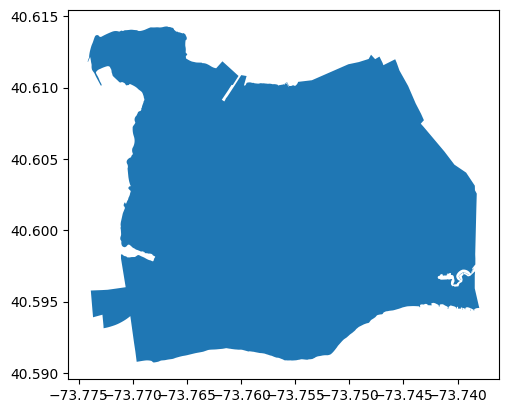

In [12]:
far_rockaway_gdf.plot()

In [13]:
flood_zones_2050_gdf

,gridcode,join_count,fld_zone,static_bfe,abfe_0_2pc,shape_leng,shape_area,geometry
0,900.0,0.0,NaN,0.0,0.0,0.000000,0.000000e+00,"MULTIPOLYGON (((1009144.3 272810.675, 1009125...."
1,900.0,0.0,NaN,0.0,0.0,0.000000,0.000000e+00,"POLYGON ((1008744.3 272060.675, 1008720.365 27..."
2,1200.0,0.0,NaN,0.0,0.0,0.000000,0.000000e+00,"MULTIPOLYGON (((1009069.3 274539.23, 1008774.1..."
3,900.0,0.0,NaN,0.0,0.0,0.000000,0.000000e+00,"MULTIPOLYGON (((1008840.674 271774.301, 100884..."
4,1200.0,0.0,NaN,0.0,0.0,0.000000,0.000000e+00,"POLYGON ((1008137.926 271350.605, 1008109.693 ..."
...,...,...,...,...,...,...,...,...
10606,1300.0,8.0,VE,13.0,17.0,94503.216652,2.901814e+07,"POLYGON ((1024258.208 176855.005, 1024263.468 ..."
10607,1300.0,3.0,AE,12.0,17.0,7002.614257,1.095574e+06,"MULTIPOLYGON (((1024048.354 176962.134, 102398..."
10608,1300.0,8.0,VE,13.0,17.0,94503.216652,2.901814e+07,"MULTIPOLYGON (((1024048.354 176962.134, 102398..."
10609,1300.0,3.0,AE,12.0,17.0,7002.614257,1.095574e+06,"MULTIPOLYGON (((1024041.544 176962.598, 102404..."


In [14]:
base_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/MAPPLUTO/FeatureServer/0/query"
layer_wkid = 2263

all_features, offset = [], 0
while True:
    params = {
        "where": "ZipCode = 11691",
        "outFields": "CD,LandUse,UnitsRes",
        "returnGeometry": "true",
        "outSR": layer_wkid,
        "resultOffset": offset,
        "resultRecordCount": 2000,
        "f": "geojson",
    }
    r = requests.get(base_url, params=params)
    r.raise_for_status()
    fc = r.json()
    if "error" in fc:
        raise RuntimeError(fc["error"])
    feats = fc.get("features", [])
    all_features.extend(feats)
    if len(feats) < 2000:
        break
    offset += 2000

In [15]:
far_rockaway_pluto_gdf = gpd.GeoDataFrame.from_features(
    all_features, crs=f"EPSG:{layer_wkid}"
)

<Axes: >

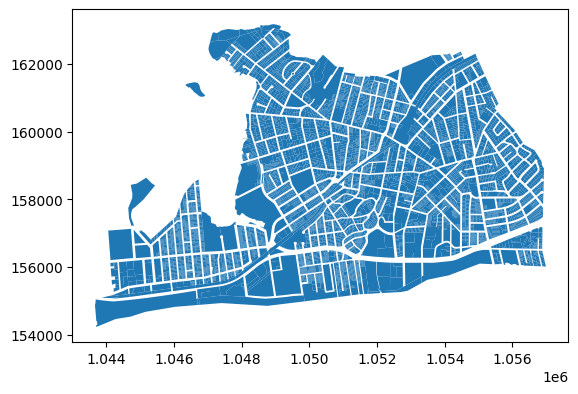

In [16]:
far_rockaway_pluto_gdf.plot()

In [17]:
flood_zones_2050_gdf.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [18]:
census_far_rockaway_gdf["bg_area"] = census_far_rockaway_gdf.geometry.area
census_far_rockaway_gdf["flooded_area 2050"] = (
    census_far_rockaway_gdf.geometry.intersection(flood_zones_2050_gdf.union_all()).area
)
census_far_rockaway_gdf["frac_flooded_2050"] = (
    census_far_rockaway_gdf["flooded_area 2050"] / census_far_rockaway_gdf["bg_area"]
)

In [19]:
census_far_rockaway_gdf["pop_in_flood_zone_2050"] = (
    census_far_rockaway_gdf["Total Pop (Race/Ethnicity)"]
    * census_far_rockaway_gdf["frac_flooded_2050"]
)

<Axes: >

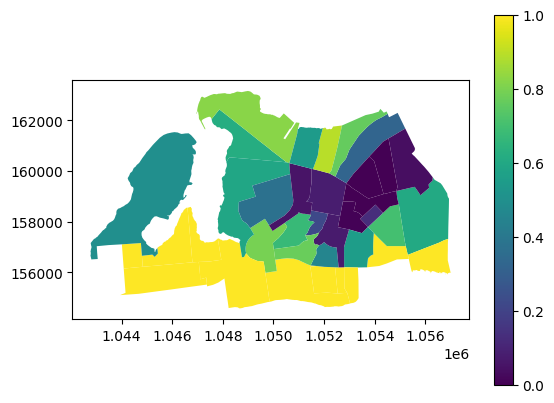

In [20]:
census_far_rockaway_gdf.plot(column="frac_flooded_2050", legend=True)

<Axes: >

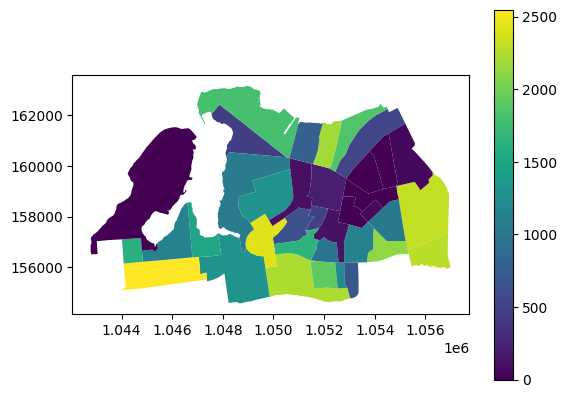

In [21]:
census_far_rockaway_gdf.plot(column="pop_in_flood_zone_2050", legend=True)

In [34]:
census_far_rockaway_gdf["pop_points"] = census_far_rockaway_gdf.apply(
    lambda row: utils.random_points_in_geom(
        row.geometry, row["Total Pop (Race/Ethnicity)"] / 10
    ),
    axis=1,
)

Text(0.5, 1.0, 'Randomly distributed population points in Far Rockaway')

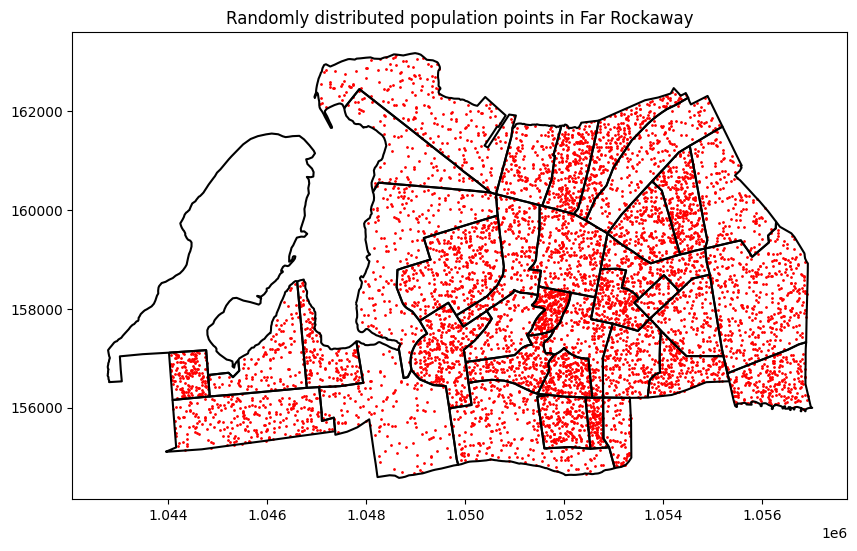

In [36]:
ax = census_far_rockaway_gdf.boundary.plot(color="black", figsize=(10, 10))
census_far_rockaway_gdf.set_geometry("pop_points").plot(
    ax=ax, color="red", markersize=1
)
ax.set_title("Randomly distributed population points in Far Rockaway")